# Pose-Based Human Action Recognition Project


In [1]:
import numpy as np
import time
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
from torch.utils.data.sampler import SubsetRandomSampler
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import os

In [2]:
ACTION_NAMES = ['standing', 'check-watch', 'cross-arms', 'scratch-head', 'sit-down',
                'get-up', 'turn', 'walk', 'wave1', 'box', 'kick', 'point', 'pick-up',
                'bend', 'hands-clap', 'wave2', 'jog', 'jump', 'pjump', 'run']

# Data Loading

In [3]:
# Mount Drive
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

!pip install -q mpose

  Preparing metadata (setup.py) ... done


In [5]:
cache_dir = '/content/drive/MyDrive/APS360/Project/data'
os.makedirs(cache_dir, exist_ok=True)
npz_path = os.path.join(cache_dir, 'mpose_posenet_split1.npz')

if os.path.exists(npz_path):
    z = np.load(npz_path)
    X_train, y_train, X_test, y_test = z['X_train'], z['y_train'], z['X_test'], z['y_test']
    print('loaded from Drive cache')
else:
    import mpose
    dataset = mpose.MPOSE(pose_extractor='posenet', split=1)   # raw keypoints, do my own data preprocessing
    dataset.get_info()
    X_train, y_train, X_test, y_test = dataset.get_data()
    np.savez_compressed(npz_path,
                        X_train=X_train, y_train=y_train,
                        X_test=X_test, y_test=y_test)
    print('downloaded + cached to Drive')

print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)


loaded from Drive cache
(12562, 30, 17, 3) (12562,) (2867, 30, 17, 3) (2867,)


In [6]:
# sanity check before data prepocessing

# check the labels in the dataset
print("y dtype:", y_train.dtype)
print("unique labels:", np.unique(y_train))
print("num classes:", len(np.unique(y_train)))
print("first 10:", y_train[:10])

# check the percentage of each class
vals, counts = np.unique(y_train, return_counts=True)
print("\nclass distribution (train):")
for v, c in zip(vals, counts):
    print(f"  class {v}: {c:5d}  ({100*c/len(y_train):.1f}%)")
print(f"imbalance ratio (max/min): {counts.max()/counts.min():.1f}x")

# check the value range per channel, needed for sample normalization
for i, name in enumerate(['x', 'y', 'conf']):
    ch = X_train[..., i]
    print(f"\n{name}: min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}")


y dtype: int64
unique labels: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19]
num classes: 20
first 10: [13 13 13 13 13 13 13 13 13 13]

class distribution (train):
  class 0:   426  (3.4%)
  class 1:   199  (1.6%)
  class 2:   288  (2.3%)
  class 3:   241  (1.9%)
  class 4:   298  (2.4%)
  class 5:   241  (1.9%)
  class 6:   227  (1.8%)
  class 7:  1872  (14.9%)
  class 8:  1070  (8.5%)
  class 9:  1537  (12.2%)
  class 10:   300  (2.4%)
  class 11:   419  (3.3%)
  class 12:   197  (1.6%)
  class 13:   369  (2.9%)
  class 14:  1441  (11.5%)
  class 15:  1826  (14.5%)
  class 16:   550  (4.4%)
  class 17:   204  (1.6%)
  class 18:   243  (1.9%)
  class 19:   614  (4.9%)
imbalance ratio (max/min): 9.5x

x: min=0.000  max=416.000  mean=200.448

y: min=0.000  max=288.000  mean=117.859

conf: min=0.000  max=0.997  mean=0.806


# Data Preprocessing

In [7]:

# keypoint indices
lhip, rhip, lshoulder, rshoulder = 11, 12, 5, 6
conf_thrhold= 0.2

def preprocess(X):
    """
    X: (N, 30, 17, 3) raw pixel keypoints (x, y, conf)
    -> (N, 30, 51) normalized + cleaned, flattened per frame
    """
    X = X.astype(np.float32).copy()   # make copy so not touch the original source data
    xy   = X[..., :2]    # (N,30,17,2)
    conf = X[..., 2:3]    # (N,30,17,1)

    # reference points, computed per frame
    mid_hip = (xy[:, :, lhip] + xy[:, :, rhip]) / 2          # (N,30,2)
    mid_sho = (xy[:, :, lshoulder] + xy[:, :, rshoulder]) / 2   # (N,30,2)
    torso   = np.linalg.norm(mid_sho - mid_hip, axis=-1)       # (N,30)
    torso   = np.clip(torso, 0.001, None)[..., None, None]      # avoid divide-by-zero

    # normalization
    # center at mid-hip, scale by torso length
    xy = (xy - mid_hip[:, :, None, :]) / torso

    # zero out low-confidence joints (position and confidence flag)
    bad = conf < conf_thrhold
    xy   = np.where(bad, 0.0, xy)
    conf = np.where(bad, 0.0, conf)

    #recombine + flatten
    X = np.concatenate([xy, conf], axis=-1)   # (N,30,17,3)
    return X.reshape(X.shape[0], X.shape[1], -1)  # (N,30,51)


In [8]:
X_train_p = preprocess(X_train)
X_test_p  = preprocess(X_test)
# sanity check; expect (12562, 30, 51) (2867, 30, 51)
print(X_train_p.shape, X_test_p.shape)

(12562, 30, 51) (2867, 30, 51)


# Data Spliting

In [9]:
from sklearn.model_selection import train_test_split

seed = 66

# split validation set out of training set
# use stratify to keep class proportions
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_p, y_train, test_size=0.176, stratify=y_train, random_state=seed)
print("train:", X_tr.shape, "val:", X_val.shape, "test:", X_test_p.shape)

# tensors -> dataLoaders
def get_data_loader(X, y, batch_size, shuffle):
    ds = TensorDataset(torch.as_tensor(X, dtype=torch.float32),
                       torch.as_tensor(y, dtype=torch.long))   #long for CrossEntropyLoss
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)

train_loader = get_data_loader(X_tr,     y_tr,  batch_size=64,  shuffle=True)   # shuffle train
val_loader   = get_data_loader(X_val,    y_val, batch_size=256, shuffle=False)
test_loader  = get_data_loader(X_test_p, y_test, batch_size=256, shuffle=False)

# inverse-frequency class weights for the imbalanced loss
# used to balance different classes
counts = np.bincount(y_tr, minlength=20)
class_weights = torch.tensor(counts.sum() / (len(counts) * counts), dtype=torch.float32)
print(f"class weights range: {class_weights.min().item():.3f} -> {class_weights.max().item():.3f}")


train: (10351, 30, 51) val: (2211, 30, 51) test: (2867, 30, 51)
class weights range: 0.335 -> 3.195


# Base line model


In [10]:
from sklearn.metrics import accuracy_score, f1_score

1 Majority-class Baseline


> Prove that the model is learning






In [ ]:

#get the most frequent class in the traning data set
majority_class = np.bincount(y_tr).argmax()
print("most frequent training class:", majority_class)

#let the baseline predict the majority class
y_pred = np.full_like(y_val, fill_value=majority_class)

# score it
acc = accuracy_score(y_val, y_pred)
macro_f1 = f1_score(y_val, y_pred, average='macro')
print(f"Majority-class baseline: accuracy: {acc:.3f}   macro-F1: {macro_f1:.3f}")


most frequent training class: 7
Majority-class baseline: accuracy: 0.149   macro-F1: 0.013


Helper functions

In [15]:
import copy

def evaluate(model, loader, criterion, device=('cuda' if torch.cuda.is_available() else 'cpu')):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad(): # no gradient tracking for evaluation
      for X, y in loader:
          X, y = X.to(device), y.to(device)
          #evaluate on data set
          outputs = model(X)
          loss = criterion(outputs, y)
          pred = outputs.argmax(dim=1).cpu()
          total_loss += loss.item()
          all_preds.append(pred)
          all_labels.append(y.cpu())
    model.train()
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()
    return (total_loss / len(loader),
            accuracy_score(all_labels, all_preds),
            f1_score(all_labels, all_preds, average='macro'))

def train(model, train_loader, val_loader, class_weights, device=('cuda' if torch.cuda.is_available() else 'cpu'),
          epochs=60, lr=0.001, tolerance = 10, weight_decay=0.0):
    model.to(device)

    # loss function and optimizer
    criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay = weight_decay)

    history = {'train_loss': [], 'val_loss': [], 'val_acc': [], 'val_f1': []} # place holder for error and loss
    best_f1, best_state, no_improve = -1.0, None, 0      # track best F1 score, best set of weights and no improvements count

    for epoch in range(epochs):
        running = 0.0
        for X, y in train_loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            # forward pass, loss calculation, backward pass, update weights
            outputs = model(X)
            loss = criterion(outputs, y)
            loss.backward()
            optimizer.step()
            running += loss.item()
           #  stats
        train_loss = running / len(train_loader)

        val_loss, val_acc, val_f1 = evaluate(model, val_loader, criterion, device)

        # append the training data after each epoch
        for k, v in zip(history, [train_loss, val_loss, val_acc, val_f1]):
            history[k].append(v)
        print(f"epoch {epoch+1:2d}  train_loss {train_loss:.3f}  "
              f"val_loss {val_loss:.3f}  acc {val_acc:.3f}  macroF1 {val_f1:.3f}")

        if val_f1 > best_f1:                       # early stopping on val macro-F1
            best_f1, best_state, no_improve = val_f1, copy.deepcopy(model.state_dict()), 0
        else:
            no_improve += 1
            if no_improve >= tolerance:
                print(f"early stop @ epoch {epoch+1} (best macroF1 {best_f1:.3f})")
                break

    model.load_state_dict(best_state)              # restore best weights
    return history


def plot_training_curve(history, title=""):
    epochs = range(1, len(history['train_loss']) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))

    # train vs validation loss
    ax1.plot(epochs, history['train_loss'], label="Train")
    ax1.plot(epochs, history['val_loss'],   label="Validation")
    ax1.set_title(f"{title} — Loss"); ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
    ax1.legend(loc='best')

    # validation accuracy and macro_f1
    ax2.plot(epochs, history['val_acc'], label="Val accuracy")
    ax2.plot(epochs, history['val_f1'],  label="Val macro-F1")
    ax2.set_title(f"{title} — Validation metrics"); ax2.set_xlabel("Epoch"); ax2.set_ylabel("Score")
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.show()

def get_predictions(model, loader, device = ('cuda' if torch.cuda.is_available() else 'cpu')):
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
      for X, y in loader:
          y_pred.append(model(X.to(device)).argmax(1).cpu())
          y_true.append(y)
    model.train()
    return torch.cat(y_true).numpy(), torch.cat(y_pred).numpy()

# add velocity feature
def add_velocity(X):                       # X: (N,30,51) -> (N,30,102)
    vel = np.zeros_like(X)
    vel[:, 1:] = X[:, 1:] - X[:, :-1]
    return np.concatenate([X, vel], axis=-1)



2 MLP baseline bodel (average pose recognition)


> compare with the RNN model which takes a 30 frame input



In [ ]:
class AvgPoseMLP(nn.Module):
    def __init__(self, in_dim=51, n_classes=20, p_drop=0.5):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, 128), nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(128, 64),     nn.ReLU(), nn.Dropout(p_drop),
            nn.Linear(64, n_classes),
        )
    def forward(self, x):            # (batch, 30, 51)
        x = x.mean(dim=1)            # average over the 30 frames (batch, 51)
        return self.net(x)           # logits (batch, 20)




Train average MLP model

> Quantitative result












epoch  1  train_loss 2.874  val_loss 2.577  acc 0.307  macroF1 0.141
epoch  2  train_loss 2.465  val_loss 2.201  acc 0.423  macroF1 0.241
epoch  3  train_loss 2.265  val_loss 2.082  acc 0.430  macroF1 0.270
epoch  4  train_loss 2.170  val_loss 2.010  acc 0.458  macroF1 0.288
epoch  5  train_loss 2.104  val_loss 1.926  acc 0.480  macroF1 0.341
epoch  6  train_loss 2.053  val_loss 1.885  acc 0.494  macroF1 0.337
epoch  7  train_loss 2.019  val_loss 1.838  acc 0.496  macroF1 0.352
epoch  8  train_loss 1.968  val_loss 1.833  acc 0.499  macroF1 0.372
epoch  9  train_loss 1.947  val_loss 1.776  acc 0.492  macroF1 0.373
epoch 10  train_loss 1.913  val_loss 1.741  acc 0.499  macroF1 0.384
epoch 11  train_loss 1.878  val_loss 1.733  acc 0.478  macroF1 0.364
epoch 12  train_loss 1.848  val_loss 1.677  acc 0.509  macroF1 0.404
epoch 13  train_loss 1.830  val_loss 1.662  acc 0.517  macroF1 0.416
epoch 14  train_loss 1.818  val_loss 1.659  acc 0.515  macroF1 0.409
epoch 15  train_loss 1.787  val_lo

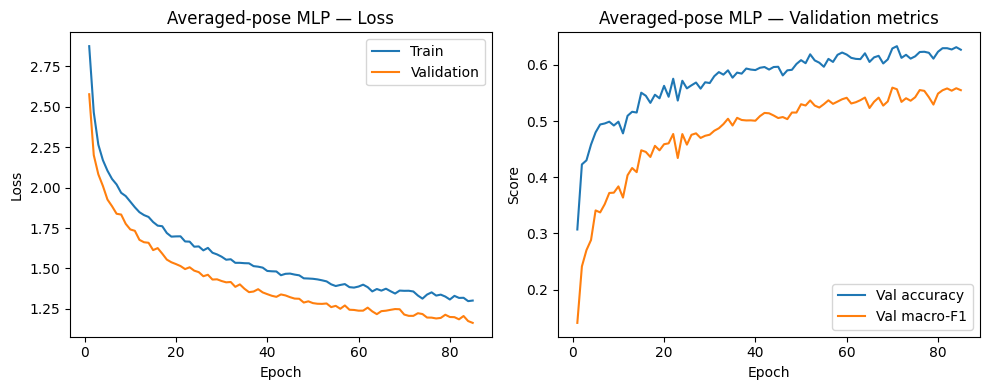

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.manual_seed(66)
mlp = AvgPoseMLP()
history_mlp = train(mlp, train_loader, val_loader, class_weights, device, epochs = 100, tolerance = 15)

plot_training_curve(history_mlp, title="Averaged-pose MLP")



> Save check point on the drive to avoid rerun



In [12]:
checkpoint_dir = '/content/drive/MyDrive/APS360/Project/checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)







> Qualitative result







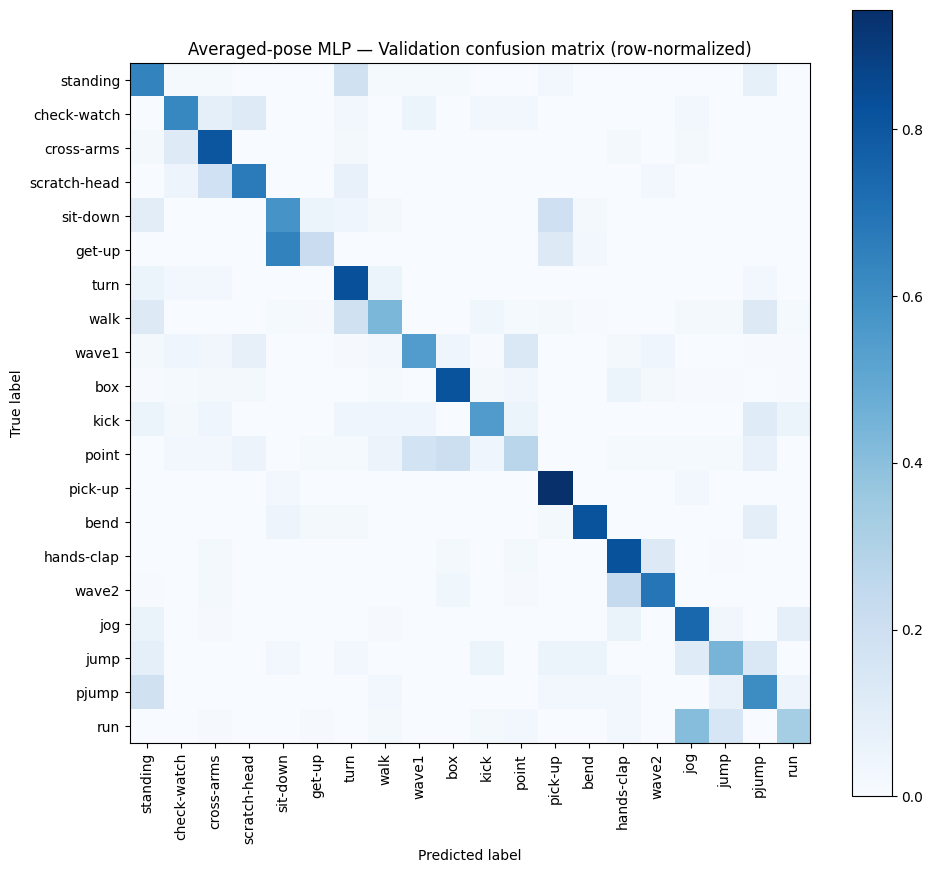

In [ ]:

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Save the best weights
torch.save(mlp.state_dict(), f"{checkpoint_dir}/mlp_baseline.pt")

#predictions on the validation set
y_true, y_pred = get_predictions(mlp, val_loader, device)

#row-normalized confusion matrix (each true-class row sums to 1)
cm = confusion_matrix(y_true, y_pred, normalize='true')

#plot the heatmap
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm, display_labels=ACTION_NAMES).plot(
    ax=ax, cmap='Blues', include_values=False, colorbar=True, xticks_rotation='vertical')
ax.set_title("Averaged-pose MLP — Validation confusion matrix (row-normalized)")
plt.tight_layout(); plt.show()




In [ ]:
off = cm.copy()
np.fill_diagonal(off, 0.0)                   # ignore correct predictions
top = np.argsort(off, axis=None)[::-1][:10]  # 10 largest off-diagonal entries
for idx in top:
    i, j = np.unravel_index(idx, off.shape)
    print(f"{ACTION_NAMES[i]:>12} (true) -> {ACTION_NAMES[j]:<12} (pred):  {off[i, j]:.2f}")


      get-up (true) -> sit-down     (pred):  0.64
         run (true) -> jog          (pred):  0.41
       wave2 (true) -> hands-clap   (pred):  0.24
       point (true) -> box          (pred):  0.20
    sit-down (true) -> pick-up      (pred):  0.19
scratch-head (true) -> cross-arms   (pred):  0.19
    standing (true) -> turn         (pred):  0.19
       pjump (true) -> standing     (pred):  0.19
        walk (true) -> turn         (pred):  0.19
       point (true) -> wave1        (pred):  0.18


# Primary Model (LSTM)

In [20]:
class PoseRNN(nn.Module):
    def __init__(self, in_dim=51, hidden=128, num_layers=1, n_classes=20, p_drop=0.3, bidirectional=False,readout='last'):
        super().__init__()
        self.bidirectional = bidirectional
        self.readout = readout
        self.lstm = nn.LSTM(input_size=in_dim, hidden_size=hidden,
                            num_layers=num_layers, batch_first=True,
                            dropout=p_drop if num_layers > 1 else 0.0,
                            bidirectional=bidirectional)
        H = hidden * (2 if bidirectional else 1)
        fc_in = H * (2 if readout == 'meanmax' else 1)
        self.dropout = nn.Dropout(p_drop)
        self.fc = nn.Linear(fc_in, n_classes)

    def forward(self, x):                         # x: (batch, 30, 51)
        out, (h_n, _) = self.lstm(x)                 # h_n: (num_layers * directions, batch, hidden)
        if self.readout == 'meanmax':
          feat = torch.cat([out.mean(dim=1), out.max(dim=1).values], dim=1)  # (batch, 2H)
        elif self.bidirectional:
            feat = torch.cat((h_n[-2], h_n[-1]), dim=1)  # top layer forward + backward states
        else:
            feat = h_n[-1]                         # top layer final hidden state
        return self.fc(self.dropout(feat))         # logits (batch, 20)




> # train primary model



epoch  1  train_loss 2.483  val_loss 2.086  acc 0.408  macroF1 0.245
epoch  2  train_loss 2.033  val_loss 1.922  acc 0.425  macroF1 0.326
epoch  3  train_loss 1.885  val_loss 1.839  acc 0.500  macroF1 0.352
epoch  4  train_loss 1.762  val_loss 1.784  acc 0.404  macroF1 0.358
epoch  5  train_loss 1.662  val_loss 1.637  acc 0.474  macroF1 0.418
epoch  6  train_loss 1.550  val_loss 1.499  acc 0.539  macroF1 0.424
epoch  7  train_loss 1.436  val_loss 1.405  acc 0.583  macroF1 0.486
epoch  8  train_loss 1.375  val_loss 1.319  acc 0.608  macroF1 0.515
epoch  9  train_loss 1.305  val_loss 1.243  acc 0.649  macroF1 0.550
epoch 10  train_loss 1.208  val_loss 1.220  acc 0.647  macroF1 0.548
epoch 11  train_loss 1.159  val_loss 1.208  acc 0.648  macroF1 0.568
epoch 12  train_loss 1.111  val_loss 1.101  acc 0.667  macroF1 0.577
epoch 13  train_loss 1.054  val_loss 1.147  acc 0.699  macroF1 0.603
epoch 14  train_loss 1.006  val_loss 1.127  acc 0.696  macroF1 0.601
epoch 15  train_loss 0.961  val_lo

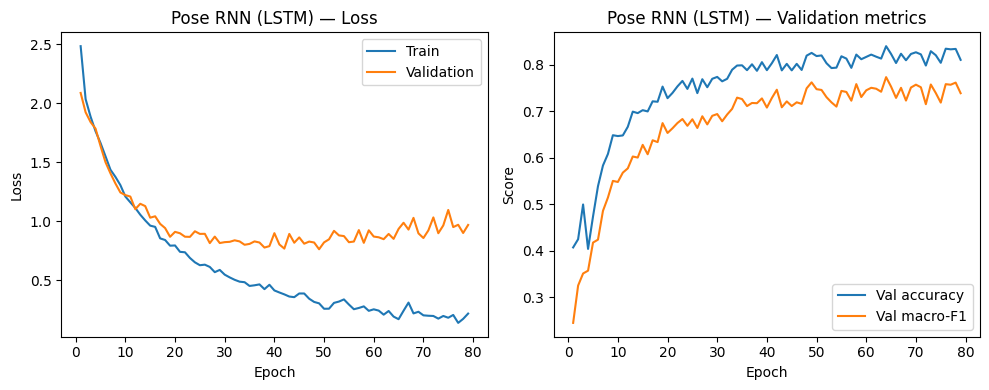

In [ ]:
torch.manual_seed(66)
pose_net = PoseRNN()
history_rnn = train(pose_net, train_loader, val_loader, class_weights,
                    epochs=100, tolerance=15)

plot_training_curve(history_rnn, title="Pose RNN (LSTM)")
torch.save(pose_net.state_dict(), f"{checkpoint_dir}/pose_net_baseline.pt") # save best weights on the disk

# Model Tuning

Tuning log

| # | Config (change vs. champion)        | Val acc | Val macro-F1 | Stop ep. | Verdict |
|---|-------------------------------------|---------|--------------|----------|---------|
| 0 | 1-layer LSTM, h=128, drop 0.3 (base)| 0.840   | 0.773        | 79       | champion → beaten |
| 1 | num_layers=2 (+inter-layer dropout) | 0.871   | 0.819        | 82       | champion |
| 2 | + weight_decay=1e-4 (on 2-layer)    | 0.858   | 0.808        | 93       | not adopted (−0.011, within noise) |
| 3 | hidden=256 (on 2-layer)             | 0.858   | 0.804        | 54       | not adopted (−0.015, within noise) |
| 4 | bidirectional=True (on 2-layer)     | 0.870   | 0.823    | 82       | not adopted (+0.004 within noise) |
| 5 | mean+max pool readout (on 2-layer)  | 0.872   | 0.826        | 82       | not adopted (+0.007, within noise) |
| 6 | velocity features (in_dim=102, 2-layer) | 0.858 | 0.805 | 64 | not adopted (−0.014, within noise) |





2-layer LSTM

epoch  1  train_loss 2.440  val_loss 2.175  acc 0.395  macroF1 0.252
epoch  2  train_loss 2.004  val_loss 1.888  acc 0.437  macroF1 0.341
epoch  3  train_loss 1.866  val_loss 1.749  acc 0.500  macroF1 0.355
epoch  4  train_loss 1.691  val_loss 1.689  acc 0.460  macroF1 0.363
epoch  5  train_loss 1.551  val_loss 1.462  acc 0.590  macroF1 0.473
epoch  6  train_loss 1.454  val_loss 1.370  acc 0.546  macroF1 0.466
epoch  7  train_loss 1.345  val_loss 1.338  acc 0.613  macroF1 0.510
epoch  8  train_loss 1.230  val_loss 1.137  acc 0.612  macroF1 0.551
epoch  9  train_loss 1.181  val_loss 1.508  acc 0.587  macroF1 0.465
epoch 10  train_loss 1.145  val_loss 1.130  acc 0.655  macroF1 0.580
epoch 11  train_loss 1.059  val_loss 1.073  acc 0.692  macroF1 0.604
epoch 12  train_loss 1.003  val_loss 1.033  acc 0.704  macroF1 0.619
epoch 13  train_loss 0.974  val_loss 1.019  acc 0.691  macroF1 0.608
epoch 14  train_loss 0.880  val_loss 0.959  acc 0.701  macroF1 0.621
epoch 15  train_loss 0.808  val_lo

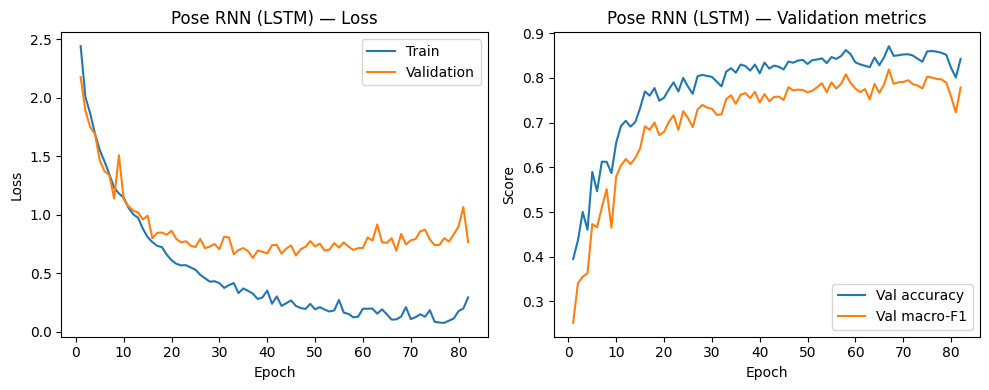

In [ ]:
# 2 layer, more temporal depth
torch.manual_seed(66)
rnn2 = PoseRNN(num_layers=2)          # the ONLY change vs. the baseline config
history_rnn2 = train(rnn2, train_loader, val_loader, class_weights,
                     epochs=100, tolerance=15)
plot_training_curve(history_rnn2, title="Pose RNN (LSTM)")
torch.save(rnn2.state_dict(), f"{checkpoint_dir}/rnn_2layer.pt")

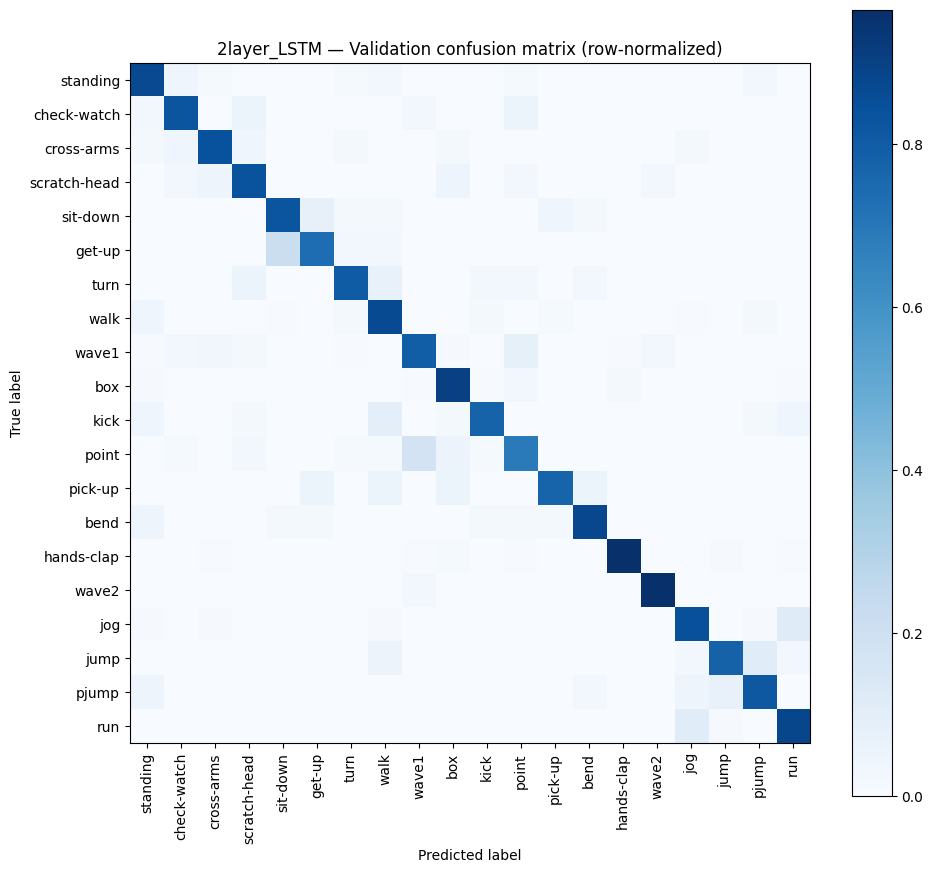

In [ ]:
#predictions on the validation set
y_true, y_pred = get_predictions(rnn2, val_loader)

#row-normalized confusion matrix (each true-class row sums to 1)
cm = confusion_matrix(y_true, y_pred, normalize='true')

#plot the heatmap
fig, ax = plt.subplots(figsize=(10, 9))
ConfusionMatrixDisplay(cm, display_labels=ACTION_NAMES).plot(
    ax=ax, cmap='Blues', include_values=False, colorbar=True, xticks_rotation='vertical')
ax.set_title("2layer_LSTM — Validation confusion matrix (row-normalized)")
plt.tight_layout(); plt.show()


In [ ]:
off = cm.copy()
np.fill_diagonal(off, 0.0)                   # ignore correct predictions
top = np.argsort(off, axis=None)[::-1][:10]  # 10 largest off-diagonal entries
for idx in top:
    i, j = np.unravel_index(idx, off.shape)
    print(f"{ACTION_NAMES[i]:>12} (true) -> {ACTION_NAMES[j]:<12} (pred):  {off[i, j]:.2f}")

      get-up (true) -> sit-down     (pred):  0.21
       point (true) -> wave1        (pred):  0.18
         jog (true) -> run          (pred):  0.11
        jump (true) -> pjump        (pred):  0.11
         run (true) -> jog          (pred):  0.11
        kick (true) -> walk         (pred):  0.09
       wave1 (true) -> point        (pred):  0.08
    sit-down (true) -> get-up       (pred):  0.08
        turn (true) -> walk         (pred):  0.07
       pjump (true) -> jump         (pred):  0.07


2-layer weight_decay LSTM

epoch  1  train_loss 2.466  val_loss 2.145  acc 0.336  macroF1 0.224
epoch  2  train_loss 1.990  val_loss 1.940  acc 0.406  macroF1 0.310
epoch  3  train_loss 1.845  val_loss 1.761  acc 0.496  macroF1 0.342
epoch  4  train_loss 1.763  val_loss 1.618  acc 0.502  macroF1 0.423
epoch  5  train_loss 1.550  val_loss 1.496  acc 0.603  macroF1 0.465
epoch  6  train_loss 1.474  val_loss 1.488  acc 0.566  macroF1 0.463
epoch  7  train_loss 1.380  val_loss 1.329  acc 0.614  macroF1 0.515
epoch  8  train_loss 1.277  val_loss 1.229  acc 0.621  macroF1 0.540
epoch  9  train_loss 1.221  val_loss 1.320  acc 0.571  macroF1 0.482
epoch 10  train_loss 1.140  val_loss 1.115  acc 0.672  macroF1 0.591
epoch 11  train_loss 1.049  val_loss 1.058  acc 0.664  macroF1 0.593
epoch 12  train_loss 1.013  val_loss 1.055  acc 0.673  macroF1 0.585
epoch 13  train_loss 0.968  val_loss 1.006  acc 0.680  macroF1 0.625
epoch 14  train_loss 0.884  val_loss 0.965  acc 0.688  macroF1 0.618
epoch 15  train_loss 0.862  val_lo

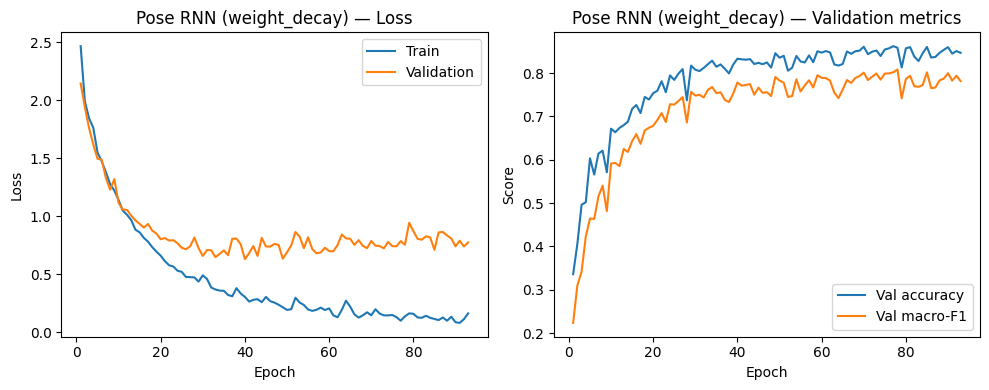

In [ ]:
# weight decay on the 2-layer champion
torch.manual_seed(66)
rnn_wd = PoseRNN(num_layers=2)
history_wd = train(rnn_wd, train_loader, val_loader, class_weights,
                   epochs=100, tolerance=15, weight_decay=1e-4)
plot_training_curve(history_wd, title="Pose RNN (weight_decay)")
torch.save(rnn_wd.state_dict(), f"{checkpoint_dir}/rnn_wd.pt")

Increase capacity

epoch  1  train_loss 2.366  val_loss 2.242  acc 0.322  macroF1 0.193
epoch  2  train_loss 2.031  val_loss 1.836  acc 0.474  macroF1 0.343
epoch  3  train_loss 1.787  val_loss 1.804  acc 0.450  macroF1 0.345
epoch  4  train_loss 1.665  val_loss 1.570  acc 0.540  macroF1 0.429
epoch  5  train_loss 1.455  val_loss 1.449  acc 0.558  macroF1 0.457
epoch  6  train_loss 1.389  val_loss 1.353  acc 0.593  macroF1 0.496
epoch  7  train_loss 1.243  val_loss 1.202  acc 0.646  macroF1 0.546
epoch  8  train_loss 1.167  val_loss 1.280  acc 0.601  macroF1 0.508
epoch  9  train_loss 1.087  val_loss 1.092  acc 0.668  macroF1 0.583
epoch 10  train_loss 0.980  val_loss 1.103  acc 0.651  macroF1 0.572
epoch 11  train_loss 0.911  val_loss 0.960  acc 0.726  macroF1 0.637
epoch 12  train_loss 0.854  val_loss 0.980  acc 0.713  macroF1 0.624
epoch 13  train_loss 0.853  val_loss 0.864  acc 0.734  macroF1 0.665
epoch 14  train_loss 0.738  val_loss 0.840  acc 0.748  macroF1 0.663
epoch 15  train_loss 0.667  val_lo

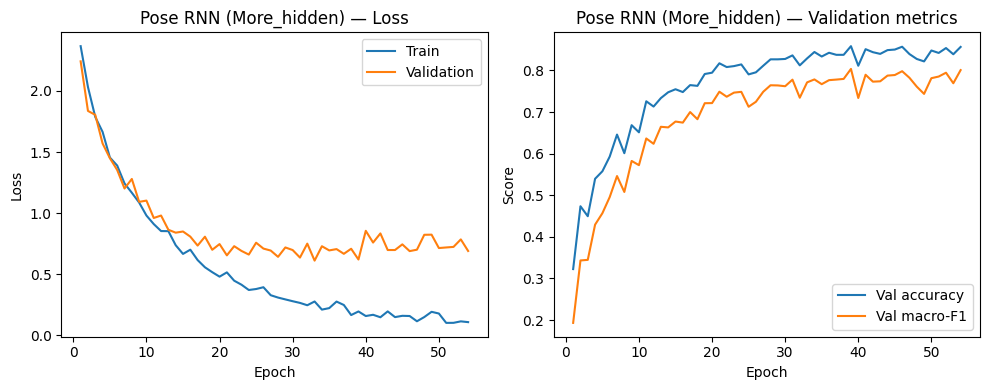

In [ ]:
#more hidden layer on 2-layer champion
torch.manual_seed(66)
rnn_hid = PoseRNN(num_layers=2, hidden = 256)          # change the hidden layer
history_hid = train(rnn_hid, train_loader, val_loader, class_weights,
                     epochs=100, tolerance=15)
plot_training_curve(history_hid, title="Pose RNN (More_hidden)")
torch.save(rnn_hid.state_dict(), f"{checkpoint_dir}/rnn_hid.pt")

Bidirectional LSTM

`bidirectional=True` reads each 30-frame sequence both ways.


epoch  1  train_loss 2.342  val_loss 1.949  acc 0.462  macroF1 0.319
epoch  2  train_loss 1.861  val_loss 1.667  acc 0.481  macroF1 0.376
epoch  3  train_loss 1.647  val_loss 1.560  acc 0.534  macroF1 0.420
epoch  4  train_loss 1.467  val_loss 1.411  acc 0.541  macroF1 0.468
epoch  5  train_loss 1.386  val_loss 1.333  acc 0.582  macroF1 0.496
epoch  6  train_loss 1.257  val_loss 1.192  acc 0.654  macroF1 0.569
epoch  7  train_loss 1.162  val_loss 1.180  acc 0.653  macroF1 0.561
epoch  8  train_loss 1.047  val_loss 1.051  acc 0.669  macroF1 0.581
epoch  9  train_loss 0.971  val_loss 1.157  acc 0.631  macroF1 0.560
epoch 10  train_loss 0.913  val_loss 0.956  acc 0.729  macroF1 0.651
epoch 11  train_loss 0.815  val_loss 0.968  acc 0.723  macroF1 0.631
epoch 12  train_loss 0.762  val_loss 0.847  acc 0.747  macroF1 0.673
epoch 13  train_loss 0.697  val_loss 0.851  acc 0.763  macroF1 0.684
epoch 14  train_loss 0.675  val_loss 0.863  acc 0.755  macroF1 0.667
epoch 15  train_loss 0.622  val_lo

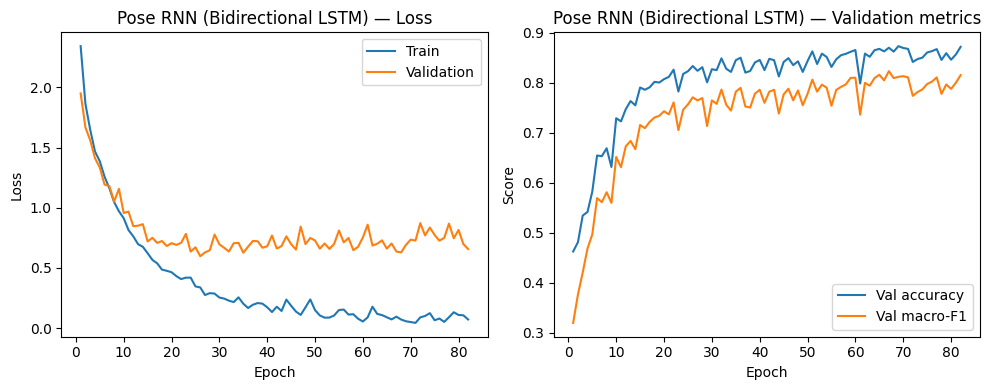

In [ ]:
# Bidirectional 2-layer LSTM
torch.manual_seed(66)
rnn_bi = PoseRNN(num_layers=2, bidirectional=True)
history_bi = train(rnn_bi, train_loader, val_loader, class_weights,
                   epochs=100, tolerance=15)
plot_training_curve(history_bi, title="Pose RNN (Bidirectional LSTM)")
torch.save(rnn_bi.state_dict(), f"{checkpoint_dir}/rnn_bidirectional.pt")

mean + max pooling

epoch  1  train_loss 2.387  val_loss 1.925  acc 0.519  macroF1 0.331
epoch  2  train_loss 1.803  val_loss 1.625  acc 0.587  macroF1 0.430
epoch  3  train_loss 1.601  val_loss 1.446  acc 0.586  macroF1 0.475
epoch  4  train_loss 1.435  val_loss 1.300  acc 0.629  macroF1 0.522
epoch  5  train_loss 1.300  val_loss 1.262  acc 0.632  macroF1 0.527
epoch  6  train_loss 1.171  val_loss 1.081  acc 0.686  macroF1 0.586
epoch  7  train_loss 1.067  val_loss 0.989  acc 0.722  macroF1 0.633
epoch  8  train_loss 0.946  val_loss 0.951  acc 0.721  macroF1 0.629
epoch  9  train_loss 0.879  val_loss 0.896  acc 0.753  macroF1 0.666
epoch 10  train_loss 0.817  val_loss 0.869  acc 0.752  macroF1 0.653
epoch 11  train_loss 0.752  val_loss 0.825  acc 0.760  macroF1 0.688
epoch 12  train_loss 0.701  val_loss 0.770  acc 0.764  macroF1 0.698
epoch 13  train_loss 0.653  val_loss 0.727  acc 0.778  macroF1 0.712
epoch 14  train_loss 0.618  val_loss 0.680  acc 0.788  macroF1 0.717
epoch 15  train_loss 0.599  val_lo

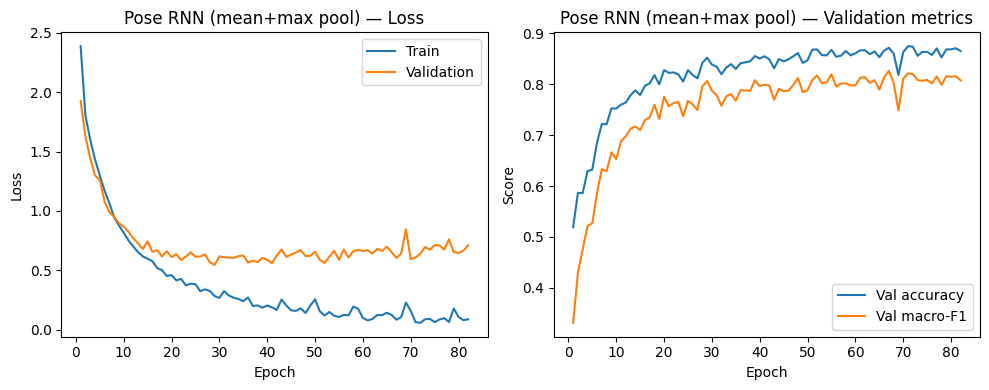

In [14]:
# mean+max pooling readout on the 2-layer champion
torch.manual_seed(66)
rnn_pool = PoseRNN(num_layers=2, readout='meanmax')
history_pool = train(rnn_pool, train_loader, val_loader, class_weights,
                     epochs=100, tolerance=15)
plot_training_curve(history_pool, title="Pose RNN (mean+max pool)")
torch.save(rnn_pool.state_dict(), f"{checkpoint_dir}/rnn_meanmax.pt")


Velocity feature

In [16]:
# velocity-augmented features: (N,30,51) -> (N,30,102)
X_tr_v  = add_velocity(X_tr)
X_val_v = add_velocity(X_val)
X_te_v  = add_velocity(X_test_p)
print(X_tr_v.shape)   # expect (10351, 30, 102)

# new loaders — reuse get_data_loader, keep separate from the 51-dim originals
train_loader_v = get_data_loader(X_tr_v,  y_tr,   batch_size=64,  shuffle=True)
val_loader_v   = get_data_loader(X_val_v, y_val,  batch_size=256, shuffle=False)
test_loader_v  = get_data_loader(X_te_v,  y_test, batch_size=256, shuffle=False)


(10351, 30, 102)


epoch  1  train_loss 2.442  val_loss 2.028  acc 0.427  macroF1 0.263
epoch  2  train_loss 1.939  val_loss 1.892  acc 0.437  macroF1 0.310
epoch  3  train_loss 1.735  val_loss 1.633  acc 0.533  macroF1 0.420
epoch  4  train_loss 1.575  val_loss 1.466  acc 0.601  macroF1 0.480
epoch  5  train_loss 1.406  val_loss 1.413  acc 0.621  macroF1 0.505
epoch  6  train_loss 1.254  val_loss 1.164  acc 0.657  macroF1 0.544
epoch  7  train_loss 1.244  val_loss 1.214  acc 0.680  macroF1 0.563
epoch  8  train_loss 1.114  val_loss 1.169  acc 0.662  macroF1 0.569
epoch  9  train_loss 1.074  val_loss 0.987  acc 0.720  macroF1 0.631
epoch 10  train_loss 0.939  val_loss 0.981  acc 0.723  macroF1 0.634
epoch 11  train_loss 0.892  val_loss 0.954  acc 0.717  macroF1 0.638
epoch 12  train_loss 0.886  val_loss 0.949  acc 0.720  macroF1 0.633
epoch 13  train_loss 0.838  val_loss 0.897  acc 0.746  macroF1 0.667
epoch 14  train_loss 0.737  val_loss 0.891  acc 0.733  macroF1 0.653
epoch 15  train_loss 0.703  val_lo

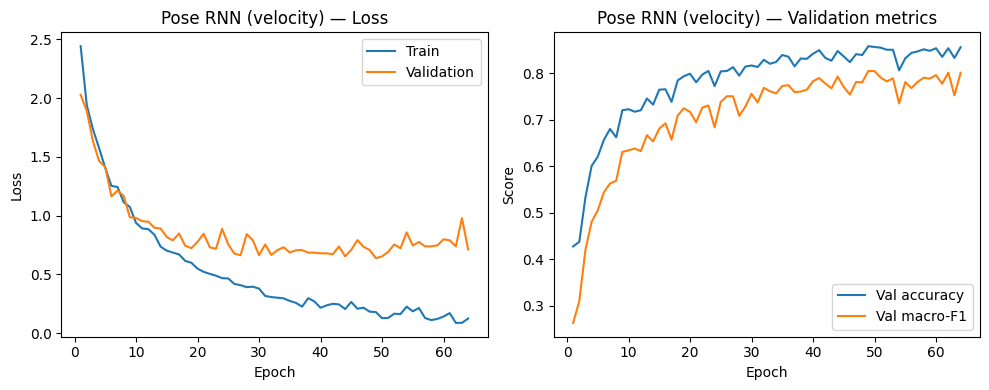

In [21]:
torch.manual_seed(66)
rnn_vel = PoseRNN(in_dim=102, num_layers=2)      # only model change: in_dim 51 -> 102
history_vel = train(rnn_vel, train_loader_v, val_loader_v, class_weights,
                    epochs=100, tolerance=15)
plot_training_curve(history_vel, title="Pose RNN (velocity)")
torch.save(rnn_vel.state_dict(), f"{checkpoint_dir}/rnn_velocity.pt")
